In [4]:
import os
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from youtube_transcript_api import YouTubeTranscriptApi, NoTranscriptFound
import yt_dlp

import operator
from typing import TypedDict, List, Annotated

from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, START, END

load_dotenv()

/Users/prathammungekar/Git Repo/Repurposely/.venv/lib/python3.12/site-packages/langgraph/cache/base/__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


True

In [5]:
class VideoContext(BaseModel):
    tone: str
    audience: List[str]
    key_takeaways: List[str]
    category: List[str]
    intent: str


In [15]:
class SingleTweet(BaseModel):
    text: str
    selection_reason: str


class ThreadTweet(BaseModel):
    tweets: List[str]
    selection_reason: str


class TwitterPost(BaseModel):
    best_single_tweet: SingleTweet
    best_thread: ThreadTweet


In [6]:
class ContentState(TypedDict):
    video_id: str
    transcript: str
    title: str
    tags: List[str]
    video_context: VideoContext
    linkedin_post: str
    twitter_post: str


In [35]:
def transcriptionNode(state: ContentState):
    """Robust transcript fetch: prefer en/en-US, else fallback to any."""
    ytt_api = YouTubeTranscriptApi()
    transcript_list = ytt_api.list(state["video_id"])

    raw_transcript = []

    try:
        raw_transcript = transcript_list.find_transcript(["en", "en-US"]).fetch()
    except NoTranscriptFound:
        available = list(transcript_list)
        if not available:
            raise
        raw_transcript = available[0].fetch()

    full_transcript = []
    for snippet in raw_transcript.to_raw_data():
        full_transcript.append({"text":snippet['text']})

    full_text = " ".join([t["text"] for t in full_transcript])

    print("transcript node success")

    return {
        "transcript": full_text
    }



In [9]:
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0.9)

In [26]:
def videoMetadataNode(state: ContentState):
    url = "https://www.youtube.com/watch?v={}".format(state.get("video_id"))

    info = {}
    ydl_opts = {
        'quiet': True,
        'skip_download': True, # We only want info, not the file
        'force_generic_extractor': False
    }

    with yt_dlp.YoutubeDL(ydl_opts) as ydl:
        info = ydl.extract_info(url, download=False)
        
    print("transcript node success")

    return {
        "title": info.get('title'),
        "tags": info.get('tags'),
    }

In [39]:
from langchain_core.messages import HumanMessage, SystemMessage


def videoContextNode(state: ContentState):
    SYSTEM_PROMPT = """
                    You are an expert content detector and expert in content analysis and intent analysis. 
                    Your task is to analyze the content of the video and provide a detailed analysis of the content.
                    You will be given a video transcript and you need to analyze the content and provide a detailed analysis of the content
                    
                    The output should be in the following format, strictly follow the output format:
                    {{
                      "tone": "Tone of the video. i.e. professional, casual, friendly, etc.",
                      "audience": ["Audience of the video. i.e. people, business, students, corporate people  etc."],
                      "key_takeaways": ["Key takeaways of the video"],
                      "category": ["Category of the video. i.e. technology, education, business, etc."] - max 5,
                      "intent": "Intent of the video. i.e. selling, educating, entertaining, etc.",                            
                    }}
    """

    video_context = llm.with_structured_output(VideoContext).invoke([
      SystemMessage(content=SYSTEM_PROMPT),
      HumanMessage(content= f"""Analyze the following video transcript and provide a detailed analysis of the content.
                          video transcript: \n\n{state["transcript"]}\n\n """)
    ])


    return {
        "video_context": video_context
    }

In [12]:
def linkedinPostNode(state: ContentState):
    SYSTEM_PROMPT = f"""
                        You are an expert LinkedIn ghostwriter and content strategist.

                        Your task is to transform a YouTube video transcript into a high-performing LinkedIn post.

                        INPUT:
                        - Title: {state["title"]}
                        - Video Context: {state["video_context"]}
                        - Tags: {state["tags"]}
                        - Transcript: {state["transcript"]}

                        ---

                        OBJECTIVE:
                        Create a LinkedIn post that feels like it was written by a thoughtful human professional, not by AI.

                        Do not summarize the full video.
                        Find the strongest idea in the transcript and turn that one idea into a compelling LinkedIn post.

                        ---

                        ANGLE SELECTION:

                        Before writing, silently identify the strongest LinkedIn angle from the transcript.

                        Choose only ONE angle:
                        - A surprising insight
                        - A common mistake people make
                        - A contrarian opinion
                        - A practical lesson
                        - A useful framework
                        - A career/business takeaway
                        - A personal or reflective observation

                        Use the angle that is most likely to make professionals stop scrolling, think, and respond.

                        ---

                        STRICT LINKEDIN CONSTRAINTS:

                        1. Character limit:
                        - Maximum: 3,000 characters
                        - Ideal: 1,200-1,600 characters

                        2. Hook:
                        - First 2 lines must be strong and specific
                        - Create curiosity, tension, or a sharp observation
                        - Put the core idea within the first 210 characters
                        - Avoid generic hooks like:
                            - "Most people don't realize..."
                            - "Here are 5 lessons..."
                            - "This video changed how I think..."
                            - "In today's fast-paced world..."

                        3. Structure:
                        - Use short paragraphs
                        - 1-2 lines per paragraph maximum
                        - Add whitespace for mobile readability
                        - Do not use large text blocks

                        4. Tone:
                        - Clear, human, conversational
                        - Thoughtful but not preachy
                        - Professional but not corporate
                        - Slightly opinionated when appropriate
                        - Avoid robotic, overly polished, or motivational language

                        5. Content style:
                        Include at least ONE of:
                        - Story
                        - Insight
                        - Lesson
                        - Framework
                        - Contrarian opinion
                        - Practical takeaway

                        6. Value:
                        - Give the reader one clear idea they can remember
                        - Make the post useful, reflective, or actionable
                        - Use specific details from the transcript
                        - Do not invent facts, examples, quotes, numbers, or claims

                        7. CTA:
                        - End with a natural question that continues the idea
                        - Avoid generic engagement bait like:
                            - "Thoughts?"
                            - "Do you agree?"
                            - "What do you think?"

                        8. Hashtags:
                        - Include 2-4 relevant hashtags at the end
                        - Avoid broad hashtags like #success, #motivation, #growth unless directly relevant

                        ---

                        HUMAN WRITING STYLE:

                        Write like a real person sharing a sharp observation after watching the video.

                        Prefer:
                        - simple words
                        - natural rhythm
                        - specific observations
                        - mild tension
                        - concrete takeaways
                        - a few short punchy lines
                        - a few reflective sentences

                        Avoid:
                        - generic summaries
                        - "In this video..."
                        - "The speaker talks about..."
                        - "This content highlights..."
                        - corporate buzzwords
                        - fake enthusiasm
                        - excessive emojis
                        - clickbait without substance
                        - perfectly symmetrical AI-style structure
                        - phrases like "game-changer", "unlock your potential", "delve into", "leverage", "transform your journey"

                        ---

                        CONTENT TRANSFORMATION RULES:

                        Extract and use:
                        - key insights
                        - unique ideas
                        - strong opinions
                        - practical takeaways
                        - memorable lines or quotes from the transcript

                        But do not try to include everything.

                        Focus on one strong idea and make it land.

                        ---

                        OUTPUT FORMAT:

                        [Scroll-stopping hook]

                        [Specific context or observation, without saying "in this video"]

                        [Core insight]

                        [Practical takeaway, lesson, or framework]

                        [Memorable closing line]

                        [Natural CTA question]

                        [2-4 relevant hashtags]

                        ---

                        QUALITY CHECK BEFORE FINAL ANSWER:

                        Before finalizing, silently check:
                        - Is the hook specific and non-generic?
                        - Does the post focus on one strong idea?
                        - Does it sound human, not AI-written?
                        - Is it readable on mobile?
                        - Is every claim grounded in the transcript?
                        - Would a professional actually want to comment on this?

                        If the answer fails any check, revise it before responding.

                        Now generate the LinkedIn post.
                    """

    linkedin_post = llm.invoke([
        SystemMessage(content=SYSTEM_PROMPT),
        HumanMessage(content= f"""Generate a LinkedIn post using the provided video context.""")
    ])

    return {
        "linkedin_post": linkedin_post
    }
    

In [16]:
def twitterPostNode(state: ContentState):
    SYSTEM_PROMPT = f"""
                        You are an expert Twitter/X ghostwriter for technical and knowledge-driven content.

                        Your task is to convert a YouTube transcript into high-engagement Twitter content that sounds human, sharp, and platform-native.

                        INPUT:
                        - Title: {state["title"]}
                        - Video Context: {state["video_context"]}
                        - Tags: {state["tags"]}
                        - Transcript: {state["transcript"]}

                        ---

                        OBJECTIVE:
                        Generate Twitter content that is:
                        - specific (not generic)
                        - insightful (not summary-like)
                        - human (not AI-sounding)
                        - grounded in transcript content

                        Do NOT summarize the whole video.
                        Pick one strong angle and make it land.

                        ---

                        WORKFLOW (MANDATORY):

                        Step 1 (silent):
                        Identify 3 possible content angles from the transcript:
                        - contrarian insight
                        - practical lesson
                        - common mistake
                        - surprising observation
                        - framework
                        - myth vs reality

                        Step 2 (silent):
                        Pick the strongest single angle for engagement.

                        Step 3:
                        Generate:
                        A) 2 single-tweet variants
                        B) 2 thread variants (5-8 tweets each)

                        Step 4 (silent rewrite pass):
                        Rewrite each draft to remove AI tone and improve punch.

                        Step 5:
                        Score all variants (1-10) on:
                        - Hook strength
                        - Clarity
                        - Specificity
                        - Human feel
                        - Engagement potential

                        Return only:
                        - best_single_tweet
                        - best_thread
                        - one-line reason for why each was selected

                        ---

                        TWITTER CONSTRAINTS:

                        GLOBAL:
                        - Keep language crisp, conversational, and opinion-aware.
                        - Use short sentences.
                        - Avoid fluff and motivational filler.
                        - Avoid corporate tone.
                        - Use concrete details/examples from transcript when possible.
                        - No invented facts, quotes, numbers, or claims.
                        - No emojis unless truly natural (0-1 max per output).
                        - Hashtags optional; if used, max 1-2 and highly relevant.

                        SINGLE TWEET:
                        - Max 280 characters.
                        - Must contain a clear hook or insight.
                        - Should feel post-worthy without extra context.

                        THREAD:
                        - 5-8 tweets total, with max 270 characters per tweet.
                        - Tweet 1 must hook hard (curiosity/tension/claim).
                        - Each tweet should carry one idea.
                        - No tweet should feel like filler.
                        - Thread should build logically: hook -> context -> insight -> takeaway -> close.
                        - Final tweet should include a natural discussion CTA.

                        ---

                        ANTI-AI STYLE RULES (STRICT):

                        Do NOT use these phrases or similar:
                        - "game-changer"
                        - "delve into"
                        - "unlock"
                        - "leverage"
                        - "in today's fast-paced world"
                        - "let's discuss"
                        - "ever wondered"
                        - "the power of"
                        - "transform your journey"
                        - "this highlights the importance of"

                        Avoid:
                        - generic listicle tone
                        - repetitive sentence openings
                        - textbook explanations
                        - obvious AI cadence
                        - hollow inspiration

                        Prefer:
                        - strong observations
                        - concrete wording
                        - mild tension
                        - specific takeaways
                        - natural human rhythm

                        ---

                        OUTPUT FORMAT (STRICT JSON):

                        {{
                        "best_single_tweet": {{
                            "text": "...",
                            "selection_reason": "..."
                        }},
                        "best_thread": {{
                            "tweets": [
                            "1/ ...",
                            "2/ ...",
                            "3/ ..."
                            ],
                            "selection_reason": "..."
                        }}
                        }}

                        Return valid JSON only. No markdown. No extra commentary.
    """

    twitter_post = llm.with_structured_output(TwitterPost).invoke([
        SystemMessage(content=SYSTEM_PROMPT),
        HumanMessage(content= f"""Generate a Twitter post using the provided video context.""")
    ])

    return {
        "twitter_post": twitter_post
    }



In [40]:
graph = StateGraph(ContentState)

graph.add_node("transcription", transcriptionNode)
graph.add_node("video_metadata", videoMetadataNode)
graph.add_node("video_context", videoContextNode)
graph.add_node("linkedin_post", linkedinPostNode)
graph.add_node("twitter_post", twitterPostNode)

graph.add_edge(START, "transcription")
graph.add_edge(START, "video_metadata")

graph.add_edge("transcription", "video_context")
graph.add_edge("video_metadata", "video_context")

graph.add_edge("video_context", "linkedin_post")
graph.add_edge("video_context", "twitter_post")


graph.add_edge("linkedin_post", END)
graph.add_edge("twitter_post", END)

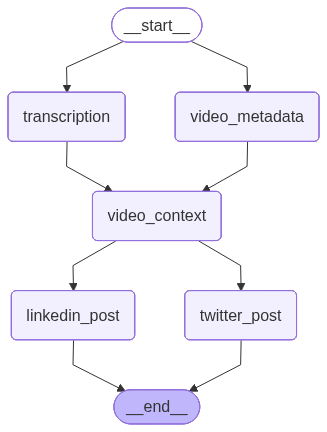

In [41]:
graph = graph.compile()
graph

In [ ]:
graph.invoke({"video_id": "MPCVGFvgVEQ"})

transcript node success
transcript node success


{'video_id': 'lWPkNkShNbo',
 'transcript': "hey siri tell me a joke if someone could just reverse the process of making wine that would be great yeah you must have used siri google assistant or alexa in your life but have you ever wondered how are these built what deep learning model do they actually use or you might have also come across grammarly suggestions or google autocomplete if you have then this series is going to be a great because from this video i'm starting a new playlist on recurrent neural network now this is the model in deep learning that is used for natural language processing or creating applications like virtual assistants or google auto complete or language translation for example converting a spanish sentence into an english sentence all these are built using recurrent neural network and in this series we will cover the mathematical details behind this model as well as at the end once we understand everything we will implement it ourselves once you understand how 